# **Class Imbalance Lab 1**

### Authors:  Mariel Concepcion, Lorenzo De Villa, Bingbong Manglicmot, Caitlin Sebastian, JF Viray
### Learning Team: 7
---

In [1]:
# Core / Utilities
from typing import Dict, Any
import os

# Data Handling & Analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# Resampling Methods
from imblearn.over_sampling import ADASYN, SMOTE, KMeansSMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek

# Preprocessing & Pipeline
from sklearn.model_selection import train_test_split

# Custom / Project-Specific Modules
from model import FraudDetector

# **1. Executive Summary**

CreditByte is a mid-sized financial services company, which struggles with fraud since criminals bypass traditional rule-based systems.  For example, many fraudulent transactions are small in amount, making them difficult to flag with just a simple threshold check. Given this complication, our main objective is to help improve the current business process in identifying fraudulent transactions in order to minimize cost. 

We propose a business process with a human in the loop. First, a Random Forest model will be used to improve fraud detection with particular attention to the heavy class imbalance between the fraudulent (0.17%) and non-fraudulent (99.83%) samples. To mitigate this imbalance, we experimented with various sampling methods to improve the model’s ability to correctly identify fraud cases. Namely, they are Random Oversampling, Random Undersampling, SMOTE, ADASYN, Tomek-Links, and Class Weighting. 

Among the sampling methods tested, Random Undersampling achieved the highest recall of 93%, but this came at the cost of terrible precision (53%), leading to many non-fraudulent transactions being incorrectly flagged. By contrast, SMOTE delivered a lower recall of 91% but significantly improved precision to 94%, representing a more balanced trade-off between recall and precision. In terms of monetary savings we assume that CreditByte uses the euro currency and we found that SMOTE is also a more practical and business-friendly choice since the company saves 3,341 euros; unlike random undersampling that has a loss of 238,896 euros. The team further built on SMOTE by combining it with other strategies but only improved marginally. Overall, our findings demonstrate how machine learning with sampling methods can enhance fraud detection for CreditByte. 

Finally, we incorporate a LIME-based explanation for a flagged transaction so that CreditByte’s investigators can easily understand why a transaction was identified as fraudulent. This ensures that our model’s predictions remain transparent and interpretable, enabling investigators to make informed judgments while maintaining oversight in the overall fraud detection process.

Our current fraud detection framework shows strong potential in improving CreditByte’s fraud monitoring, but there are ways to make it more robust. Future iterations could apply resampling directly on the original variables to ensure synthetic data reflects real fraud behavior. We may also explore hybrid resampling methods for more stable results. Finally, we recommend that rather than relying solely on automation, the model we provide should support investigators’ expertise, balancing machine intelligence with human judgment while continuously optimizing for fraud patterns and business impact.



(The project environment is set up with Python version 3.12.8.)

---

# **2. Introduction** 
In the financial industry, credit card fraud has become a pressing issue, with consumers losing $12.5 billion in 2024 alone [02]. To counter this, financial services have been utilizing machine learning to detect fraud, thereby saving both consumers and providers from losses. 


<p align="center">
  <img src="figures/01_businessprocess.png"" alt="Business Processes" width="800"/>
</p>

<b><i> Figure 1.</b> Current (a) and Proposed (b) Business Process in Determining Fraud Transactions</i>

However, CreditByte, a financial services company, has continued to rely on traditional rule-based systems as shown in Figure 1a. These methods, such as flagging questionably large transactions, are not cost-effective since at any threshold, it actually incurs the company a loss. 

Thus, this report is guided by two main objectives: 
1. To understand why older methods of thresholding and flagging unusual transaction amounts are ineffective using EDA and a new business metric
2. To improve the current business process by having more accurate predictions of fraudulent transactions using various rebalancing strategies and strengthening the role of the investigator by providing LIME-based explanations

In applying the various resampling methods for CreditByte's fraud detection, we built a model that both improves technical and business metrics to maximize company financial gains.  Ultimately, we propose a new business process in Figure 1b so that CreditByte can fight against adaptive fraud strategies. The main difference relies on the method used to classify a transaction as fraud, where we propose to use machine learning and a local interpretability method to further explain why it was flagged. 


---

# **3. Methodology**



This project follows a five-step workflow, as shown in Figure 2, beginning with exploratory data analysis (EDA) and ending with model explainability. We explore patterns in the dataset to understand the limitations of threshold-based fraud detection. Then, we developed and evaluated a Random Forest model, while addressing severe class imbalance and understanding business impact through financial metrics. Lastly, interpretability was achieved using LIME to explain individual predictions and validate human decision-making.

<p align="center">
  <img src="figures/02_methodology.jpg" alt="Methodology" width="800"/>
</p>

<b><i> Figure 2.</b> Overview of the Methodology</i>

## **3.1 Perform Exploratory Data Analysis**
Historical transaction records on fraud cases were taken from CreditByte. The dataset included anonymized PCA-transformed features (V1-V28), transaction amounts, and outcomes (fraud or non-fraud). Its dataset contains 185,124 rows by 31 columns. 

Data Dictionary: 

| Feature | Description | Data Type |
| :--- | :--- | :--- |
| **tid** | Unique transaction ID | Integer |
| **V1 – V28** | Principal Components resulting from masking sensitive features | Float |
| **Amount** | Transaction amount in Euros | Float |
| **outcome** | Target Variable (Binary): 0 = Non-fraud, 1 = Fraud | Integer |


EDA was conducted to explore patterns that differentiate fraudulent from non-fraudulent transactions, providing insights into why simple thresholding may be ineffective and which machine learning models may be useful.

## **3.2 Evaluate Threshold-based Detection and Random Forest Model**
We introduced a new metric, Net Savings, to evaluate the financial impact of how fraud was detected. It is defined as: 

$$
\text{Net Savings} = V_{\text{caught}} - V_{\text{innocently flagged}}
$$

where:  
- \( $V_{\text{caught}}$ \) = total value of fraud correctly detected  
- \( $V_{\text{innocently flagged}}$ \) = total value of innocent transactions falsely detected as fraud  

    
In addition to Net Savings, we measured the effectiveness of threshold-based fraud detection using the Fraud Capture Rate (FCR), which quantifies the proportion of actual fraud cases correctly identified. It is defined as:

$$
\text{Fraud Capture Rate} = \frac{TP_{\text{fraud}}}{TP_{\text{fraud}} + FN_{\text{fraud}}}
$$

where:  
- \( $TP_{\text{fraud}}$ \) = fraud cases correctly identified  
- \( $FN_{\text{fraud}}$ \) = fraud cases missed  

We also define the Detection Rate, which is just Macro Recall, where it measures the model’s overall ability to identify both fraudulent and legitimate transactions

$$
\text{Detection Rate} = \frac{1}{2} \bigg(\frac{TP_{\text{fraud}}}{TP_{\text{fraud}} + FN_{\text{fraud}}} + \frac{TP_{\text{nonfraud}}}{TP_{\text{nonfraud}} + FN_{\text{nonfraud}}} \bigg)
$$

For the standard evaluation metrics, we report the macro-averaged values of precision, recall, and the F1-score, which collectively provide a balanced view of the model’s predictive capability across both classes. Macro-averaging ensures that the evaluation does not favor the majority class, making it more suitable for our imbalanced dataset.
	
Additionally, Random Forest was implemented since we identified it as the most effective model for predicting fraudulent transactions.

## **3.3 Identify and handle Class Imbalance**
After analyzing the results of the EDA, several sampling strategies were tested to mitigate the problem of class imbalance. Standard methods including random undersampling, random oversampling, SMOTE, etc., were applied first. To maximize these methods, additional hybrid approaches were integrated with the best standard method found. 

These approaches include:
1. KMeans-based resampling: Clustering minority instances prior to oversampling for more diversification 
2. Tomek links: Removing questionable majority samples for clearer class boundaries 
3. Hybrid Class weighting: Combines oversampling with penalty-based learning by assigning higher weights to minority class errors
4. Proportional sampling: Balancing the ratio between majority and minority transactions 

Apart from the standard business and technical evaluation metrics (recall, precision, F1-score, detection rate, fraud capture rate, etc.), we introduced a new business metric called net value. Such implementation allows quantification of the financial implications of classification results. 



## **3.4 Explain Predictions using LIME**
We created a method called ```explain_why_fraud``` to the FraudDetector class. It takes in a transaction that was flagged as fraudulent and outputs the LIME explainer table. While LIME explains individual fraud predictions, the following exploratory data analysis and business metric evaluation show why traditional threshold-based methods fail to capture the broader patterns of fraudulent behavior.


# **4. Results and Discussion**


## **4.1 Exploratory Data Analysis**


The data shows a massive imbalance between legitimate and fraudulent transactions. Out of 180,000 records, only 305 were fraudulent (less than 0.2%). This is a big challenge for traditional fraud detection.

Current rule-based detection systems, which flag transactions above a fixed amount, are no longer effective for this data [3]. Our analysis shows that fraudulent transactions are smaller than legitimate ones. In fact, normal transactions can go above €10,000, but most fraudulent activities are below €1,000.

This pattern suggests that fraudsters keep their transactions small to avoid triggering automated alerts. So, relying on static threshold rules will leave CreditByte exposed to undetected losses. To fix this, we need more adaptive and data-driven detection methods that look at behavioral patterns rather than just transaction amount. 

In [2]:
# Define df
df = pd.read_csv("historical.csv")

# Drop tid because it is just a unique id
df = df.drop(columns=["tid"])

<p align="center">
  <img src="figures/03_histograms.png"" alt="Class Histplot" width="1000"/>
</p>

<b><i> Figure 3.</b> Histogram of Non-Fraudelent (a) and Fraudelent (b) Transaction Amounts </i>

Beyond transaction amounts, the underlying data features represented as principal components show different behaviors. Legitimate transactions show no correlation, and fraud shows strong correlation across multiple variables. So, fraud is a consistent relationship across multiple variables. This indicates that fraudulent

<p align="center">
  <img src="figures/05_heatmap.png"" alt="Correlation Heatmap" width="1000"/>
</p>

<b><i> Figure 4. </b> Correlation Heatmap of Non-Fraud and Fraud Transactions </i>

## **4.2 Evaluate Threshold-based Detection and Random Forest Model**

The net savings was designed to reward the correct identification of fraud while penalizing false detections of legitimate transactions. We tested it across multiple thresholds, ranging from the minimum to the maximum amounts of fraud transactions. As shown in Figure 5, the results support our intuition from the exploratory data analysis. At lower thresholds, a large share of fraud is captured, but financial losses increase due to the high number of false positives. At higher thresholds, fewer fraud cases are detected, but fewer innocent transactions are wrongly flagged, which reduces the net loss. However, even at the maximum threshold, the model still results in an overall net loss. Based on this financial metric, thresholding alone is not a cost-effective approach for detecting fraud.

*(As a note, we used net loss instead of net savings for clarity since net loss is simply the negative of net savings.)*


<p align="center">
  <img src="figures/04_thresholds.png"" alt="Threshold line graph" width="1000"/>
</p>

<b><i> Figure 5.</b> Fraud Capture Rate and Net Loss (Euros in Millions) based on Different Thresholds </i>

Moreover, we found that random forest was the best model for detecting fraud because it captures the complex, non-linear relationships that were previously observed in the principal component scatterplots and correlation heatmaps. As seen in Figure 4, fraudulent transactions display stronger inter-variable correlations than non-fraudulent ones, suggesting that fraud cases follow specific multivariate patterns that rule-based or threshold methods cannot identify. Random Forest, through its ensemble of decision trees, can model these intricate dependencies and effectively separate clusters.


In [3]:
X, y = df.iloc[:, :-1], df.iloc[:, -1]

# Create the training and test (hold-out) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0, stratify=y
)

# Print the shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X shape: {X.shape}")

X_train shape: (148099, 29)
X_test shape: (37025, 29)
X shape: (185124, 29)


## **4.3 Handle Class Imbalance**
### **4.3.1 Traditional Rebalancing Methods**

In [4]:
def see_metrics(result: Dict[str, Any]) -> pd.DataFrame:
    """
    Create a summary DataFrame of metrics from cross-validation results.

    Args:
        result (Dict[str, Any]): A dictionary-like object (e.g., from 
            `sklearn.model_selection.GridSearchCV.cv_results_`) containing
            mean and standard deviation test scores for metrics.

    Returns:
        pd.DataFrame: A DataFrame with metrics as rows and their mean and
        standard deviation as columns, rounded to two decimals.
    """
    # List of metric keys
    metrics = [
        "precision",
        "recall",
        "f1",
        "fcr",
        "detection",
        "abs_net_value"
    ]

    # Human-readable metric names
    formal_metrics = [
        "(Macro) Precision",
        "(Macro) Recall",
        "(Macro) F1-Score",
        "Fraud Capture Rate",
        "Detection Rate",
        "Absolute Net Value"
    ]

    # Build summary DataFrame
    summary_df = pd.DataFrame(
        {
            "Mean": [result[f"mean_test_{m}"][0] for m in metrics],
            "Standard Deviation": [
                result[f"std_test_{m}"][0] for m in metrics
            ],
        },
        index=formal_metrics,
    )

    return summary_df.round(2)


Building on the insights from the previous sections, we now turn to model evaluation and introduce standard and new key metrics to assess performance. 

While standard metrics, such as precision, recall, and F1-score, provide a general understanding of classification performance, our primary focus remains on improving the Fraud Capture Rate and Net Savings. These metrics align more closely with the project’s objective of improving the accuracy of fraud detection and ensuring a positive economic outcome for CreditByte. In particular, maximizing Fraud Capture Rate enhances the identification of fraudulent activities, while achieving positive Net Savings ensures that the detection system produces tangible financial benefits.

To improve these outcomes, we next explored various rebalancing techniques to address the data imbalance and strengthen the model’s performance metrics. We also applied Stratified K-Fold cross-validation to ensure that each fold preserved the original class proportions, allowing for a more reliable and consistent evaluation across training and validation sets. We present in Table 2 the mean scores of the validation sets.


| Method | Strategic Benefit |
| :--- | :--- |
| **Baseline (No Rebalancing)** | Kept as a performance metric to show the financial and operational benefits of rebalancing |
| **Random Undersampling (RUS)** | Used in early testing to benchmark model performance and to see the trade-offs between speed, cost, and accuracy. |
| **Random Oversampling (ROS)**| ROS’ sensitivity for fraud with minimal setup, helps us test the ROI of oversampling before moving to more advanced methods. | 
| **SMOTE** | SMOTE Chosen as the primary balancing technique because it creates more realistic and diverse training data, which results in higher fraud detection accuracy.|
| **ADASYN** | Added to detect emerging or complex fraud behaviors. |
| **Tomek Links** | Used to clean up data by removing ambiguous cases, improving prediction precision, and reducing operational losses from false positives. |
| **Class Weighting** | Used as a resource-efficient balancing solution that doesn’t increase data volume or computational cost. |

In [5]:
# Path to the summary statistics CSV file
file_path = 'spreadsheets/summary_statistics.csv'

# Check if the summary file already exists
if os.path.exists(file_path):
    # If the file exists, read it and display
    summary_df = pd.read_csv(file_path)
    display(summary_df)
else:
    # Define random seed for reproducibility
    random_seed = 92

    # Dictionary of sampling strategies for imbalanced data handling
    strategies = {
        "Baseline": None,  # No resampling
        "Random Undersampling": RandomUnderSampler(random_state=random_seed),
        "Random Oversampling": RandomOverSampler(random_state=random_seed),
        "SMOTE": SMOTE(random_state=random_seed),
        "ADASYN": ADASYN(
            random_state=random_seed, 
            n_neighbors=5, 
            sampling_strategy="minority"
        ),
        "Tomek Links": TomekLinks(sampling_strategy="auto"),
        "Class Weighting": "balanced",  # Adjust class weights instead of resampling
    }

    # Store metrics for all strategies
    all_results = []

    # Iterate over each sampling strategy
    for name, strategy in strategies.items():
        if name == "Baseline":
            # Train model without resampling
            model = FraudDetector().experiment_fit(
                X_train, y_train, sample_strategy=None
            )
        elif name == "Class Weighting":
            # Train model with class weighting instead of resampling
            model = FraudDetector().experiment_fit(
                X_train, y_train, sample_strategy=None, 
                sample_weight="balanced"
            )
        else:
            # Train model with the specified resampling strategy
            model = FraudDetector().experiment_fit(
                X_train, y_train, sample_strategy=strategy
            )
        
        # Extract evaluation metrics (mean values only)
        metrics_df = see_metrics(model)[["Mean"]]
        metrics_df.rename(columns={"Mean": name}, inplace=True)
        
        # Append results to the list
        all_results.append(metrics_df)

    # Combine results from all strategies into a single DataFrame
    summary_df = pd.concat(all_results, axis=1)

    # Save summary to CSV for future reuse
    summary_df.to_csv(file_path)

    # Display the summary
    display(summary_df)


,Unnamed: 0,Baseline,Random Undersampling,Random Oversampling,SMOTE,ADASYN,Tomek Links,Class Weighting
0,(Macro) Precision,0.97,0.52,0.97,0.95,0.94,0.96,0.98
1,(Macro) Recall,0.88,0.93,0.88,0.91,0.90,0.88,0.87
2,(Macro) F1-Score,0.92,0.53,0.92,0.93,0.92,0.91,0.92
3,Fraud Capture Rate,0.76,0.89,0.77,0.82,0.80,0.76,0.75
4,Detection Rate,0.88,0.93,0.88,0.91,0.90,0.88,0.87
5,Net Savings,-2079.44,-238896.00,3464.00,3341.00,3316.00,-2076.00,3144.63


<b><i> Table 1.</b> Metrics of Each Approach to Handling Class Imbalance </i>


Although Random Oversampling (ROS) gave slightly higher short-term savings, we decided to go with SMOTE (Synthetic Minority Oversampling Technique) as it’s more stable and reliable in the long run. ROS simply duplicates existing fraud samples and can overfit the model; SMOTE generates synthetic but realistic data points that help the model learn more diverse fraud patterns. This results in a system that generalizes better to unseen data and adapts to new or evolving fraud behaviors. Moreover, SMOTE reduces false positives by smoothing class boundaries, which lowers investigation costs and minimizes disruption to legitimate transactions. While ROS gave slightly higher immediate savings, SMOTE is a more sustainable and explainable solution that offers balanced performance, consistent fraud detection, and stronger compliance for real-world deployment.

Moreover, when we focus on our two key metrics of FCR and the Net Savings, we see that SMOTE is also the best way to handle the class imbalances. It achieves one of the highest net savings while also having a high fraud capture rate as shown in Figure 6

<p align="center">
  <img src="figures/07_tradsum.png" alt="" width="1500"/>
</p>

<b><i> Figure 6.</b> Traditional Rebalancing Methods </i>




We therefore recommend SMOTE as the approach for handling class imbalance. This claim is reinforced with the research, where they showed SMOTE can provide relevant improvements on the detection of rare fraud cases by generating synthetic minority samples that improve classifier sensitivity (Cheah, et al. 2023). Our claim is further supported by the scatterplots in Figure 5, where a clear visual separation between fraudulent and non-fraudulent clusters can be observed. This distinct boundary suggests that the underlying data structure is well-suited for synthetic oversampling techniques such as SMOTE, which can effectively expand the minority class along existing decision boundaries. However, we can build on SMOTE to see if there are hybrid strategies that can further improve our metrics.

---

### **4.3.2 Building on SMOTE** 

As seen in Figure 7, to further optimize the SMOTE method, we used various hybrid strategies such as K-means, Tomek-Links, Class weighting, and Proportional SMOTE. K-means and SMOTE helps cluster the minority samples first before generating synthetic points. This ensures that the new samples are produced in more representative regions which avoids generating noisy points. Another study also used a similar approach demonstrating that combining SMOTE-KMeans with ensemble learning shows strong performance in fraud detection, further highlighting that rebalancing is a key step for handling skewed datasets [5]. Tomek-Links and SMOTE removes borderline samples to clean overlapping instances which improves class separability. Additionally, the team implemented class weighting with SMOTE to give higher importance to the minority class during training through a weighted loss function. 

All of these three hybrid strategies used typical libraries from ```imblearn```, but the team also created proportional SMOTE to define how many fraud cases there should be. According to a study, it found that balancing classes by making the minority approximately equal to the majority class is not always optimal [4]. It mentioned that moderate oversampling sometimes gives better results but if you oversample too much, you will get diminishing returns [4]. Using less-aggressive ratios would allow us to use the least amount of synthetic data while keeping the same recall and precision performance. 


<p align="center">
  <img src="figures/09_smotebuild.png" alt="smotestrats" width="800"/>
</p>

<b><i> Figure 7.</b> Building on SMOTE: Hybrid Oversampling Strategies </i>

Based on the results of Table 2, it is notable that all of these hybrid SMOTE strategies differ marginally from the original SMOTE in terms of performance. Across various evaluation metrics, the variations are relatively small, which implies that the baseline SMOTE is already robust for this dataset. For instance, the F1-score remains consistently at 92% across all strategies which indicates that the overall balance between precision and recall is unaffected by the choice of hybrid method. 

K-means and SMOTE improves precision from 94% to 96% but lowers recall to 88%. Tomek-Links and Class weighting with SMOTE perform almost the same as its baseline suggesting limited added value. Proportional SMOTE tested at different oversampling levels, shows small differences in net value ranging from approximately 3,300 to around 3360. While Proportional SMOTE with 1200 fraud cases shows a higher net value savings and detection rate than the baseline, the 4% standard deviation indicates that the improvement may not be consistently reliable. Overall, despite their theoretical advantages, these refinements offer minor improvements over standard SMOTE for this dataset. 




In [6]:
file_path_new = 'spreadsheets/summary_smote_experiments_statistics.csv'

if os.path.exists(file_path_new):
    # Load existing results if available
    summary_new_df = pd.read_csv(file_path_new)
    display(summary_new_df)
else:
    random_seed = 92
    new_results = []

    # KMeans-SMOTE
    kmeans_smote_safe = KMeansSMOTE(
        random_state=random_seed,
        k_neighbors=3,
        kmeans_estimator=10,
        cluster_balance_threshold=0.000001,
        n_jobs=-1,
    )
    kmeans_smote_model = FraudDetector().experiment_fit(
        X_train, y_train, sample_strategy=kmeans_smote_safe
    )
    metrics_df = see_metrics(kmeans_smote_model)[["Mean"]]
    metrics_df.rename(columns={"Mean": "KMeans-SMOTE"}, inplace=True)
    new_results.append(metrics_df)

    # SMOTE + Tomek
    smote_tomek = SMOTETomek(random_state=random_seed)
    smote_tomek_model = FraudDetector().experiment_fit(
        X_train, y_train, sample_strategy=smote_tomek
    )
    metrics_df = see_metrics(smote_tomek_model)[["Mean"]]
    metrics_df.rename(columns={"Mean": "SMOTE+Tomek"}, inplace=True)
    new_results.append(metrics_df)

    # SMOTE + Class Weighting
    smote_weighting = SMOTE(random_state=random_seed)
    smote_weighting_model = FraudDetector().experiment_fit(
        X_train, y_train, sample_strategy=smote_weighting, 
        sample_weight="balanced"
    )
    metrics_df = see_metrics(smote_weighting_model)[["Mean"]]
    metrics_df.rename(columns={"Mean": "SMOTE+Weighting"}, inplace=True)
    new_results.append(metrics_df)

    # Prop-SMOTE variants
    class_counts = y_train.value_counts()
    minority_count = class_counts.min()
    target_denominators = [600, 1200, 2400]

    for denom in target_denominators:
        ratio = minority_count / denom
        model_name = f"Prop-SMOTE ({denom})"
        print(f"Running experiment for: {model_name} (Ratio: {ratio:.4f})")
        smote_sampler = SMOTE(sampling_strategy=ratio, 
                              random_state=random_seed)
        smote_model = FraudDetector().experiment_fit(
            X_train, y_train, sample_strategy=smote_sampler
        )
        metrics_df = see_metrics(smote_model)[["Mean"]]
        metrics_df.rename(columns={"Mean": model_name}, inplace=True)
        new_results.append(metrics_df)

    # Combine and save
    summary_new_df = pd.concat(new_results, axis=1)
    summary_new_df.to_csv(file_path_new, index=False)
    display(summary_new_df)


,KMeans-SMOTE,SMOTE+Tomek,SMOTE+Weighting,Prop-SMOTE (600),Prop-SMOTE (1200),Prop-SMOTE (2400)
0,0.97,0.95,0.95,0.95,0.95,0.94
1,0.89,0.91,0.91,0.91,0.92,0.92
2,0.93,0.93,0.93,0.93,0.93,0.93
3,0.79,0.82,0.82,0.83,0.83,0.83
4,0.89,0.91,0.91,0.91,0.92,0.92
5,3128.56,3323.96,3340.68,3336.38,3358.52,3271.40


<b><i> Table 2.</b> Metrics of SMOTE Hybrid Strategies </i>

Moreover, when we focus again on our two key metrics of FCR and the Net Savings, we see that the original SMOTE is still the best way to handle the class imbalances since it achieves one of the highest net savings while also having a high fraud capture rate as shown in Figure 8

<p align="center">
  <img src="figures/08_smotesum.png" alt="smotestrats" width="1500"/>
</p>

<b><i> Figure 8.</b> Building on SMOTE: Hybrid Oversampling Strategies </i>



Based on the results of Table 2, it is notable that all of these hybrid SMOTE strategies differ marginally from the original SMOTE in terms of performance. Across various evaluation metrics, the variations are relatively small, which implies that the baseline SMOTE is already robust for this dataset. For instance, the F1-score remains consistently at 92% across all strategies which indicates that the overall balance between precision and recall is unaffected by the choice of hybrid method. 

K-means and SMOTE improves precision from 94% to 96% but lowers recall to 88%. Tomek-Links and Class weighting with SMOTE perform almost the same as its baseline suggesting limited added value. Proportional SMOTE tested at different oversampling levels, shows small differences in net value ranging from approximately 3,300 to around 3360. While Proportional SMOTE with 1200 fraud cases shows a higher net value gained and detection rate than the baseline, the 4% standard deviation indicates that the improvement may not be consistently reliable. Overall, despite their theoretical advantages, these refinements offer minor improvements over standard SMOTE for this dataset. 

---

## **4.4 Explain Predictions using LIME**

While having a predictive model is valuable through the use of the original SMOTE, it is equally important to consider the legal obligations governing its use in CreditByte’s home country. Under the General Data Protection Regulation (GDPR), which applies to all automated decision-making systems operating within the European Union, models used for credit or fraud detection must ensure transparency, accountability, and human oversight. Article 22 explicitly limits decisions made solely through automation when they have legal or similarly significant effects such as flagging or blocking a credit card transaction unless adequate safeguards are provided (European Union, 2016). These safeguards include the right to human intervention, to express one’s point of view, and to contest the decision. 

To align with these legal requirements, our proposed system incorporates a LIME-based explanatory method, ```explain_why_fraud()```, within the FraudDetector class to support CreditByte’s fraud investigators. This method generates clear, human-interpretable explanations for any transaction, thus allowing investigators to understand the reasoning behind the model’s decision. Unlike SHAP or counterfactuals, it provides simpler and more intuitive explanations on why the model made its decision rather than on detailed numeric attributions or hypothetical changes. 

Figure 9 shows an example of our implementation, displaying numbered principal components that investigators can then map to their actual names via a provided dictionary. Overall, this human-in-the-loop approach enhances interpretability, ensures GDPR compliance, and empowers investigators to make transparent, accountable decisions. As seen in figure 9, the model predicts this certain transaction as fraudulent with a 98% probability mainly influenced by strong negative values in features V17, V12, and V10 which push the prediction toward fraud. In contrast, V9 offsets this decision slightly but its small positive contribution is not enough to change the overall classification. This is one way it can be interpreted for this specific instance and this framework can be used to explain other transaction instances. 


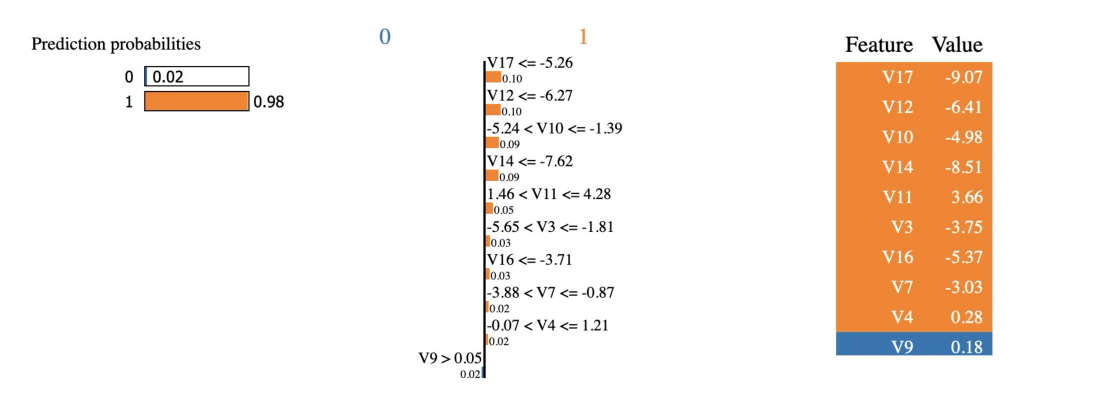

In [7]:
# Path to the LIME explanation image
image_file_path = "figures/10_lime.png"

# Check if the explanation image already exists
if os.path.exists(image_file_path):
    # Load and display the image
    img = mpimg.imread(image_file_path)
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.imshow(img)
    ax.axis("off")  # Hide axes for cleaner visualization
    plt.show()
else:
    # If the image doesn't exist, train the model and generate explanation
    final_model = FraudDetector().fit(X_train, y_train)
    
    # Select a specific transaction to explain
    transaction = X_test.loc[145417]
    
    # Generate and visualize explanation using LIME or model-specific method
    explained_inst = final_model.explain_why_fraud(transaction)

<b><i> Figure 9. </b> LIME Explanation for a Flagged Transaction </i>

## **4.5 Limitations**
While the LIME framework supports investigator decision-making, our analysis can be made more holistic by identifying areas for further expansion and improvement. First, although SMOTE effectively improved model performance, it works by generating synthetic data points with PCA components as features. Since these components no longer correspond directly to the original variables, the synthetic data may not reflect realistic transactions once mapped back to their original form. Second, while we explored several hybrid strategies on SMOTE, we did not experiment all possible hybrid combinations with other resampling methods. Our approach focused on first optimizing the traditional methods and then adding enhancements. However, there may be untested hybrid complementary techniques that could further improve model and business metrics. 


# **5. Conclusion and Recommendations** 
In conclusion, our project provides CreditByte with a clear path toward a smarter and more financially effective fraud strategy. The findings confirm that relying on static thresholds are no longer sufficient as most fraudulent transactions occur below typical flagging limits. By utilizing machine learning-based approaches and applying the SMOTE resampling method, CreditByte can better identify hidden fraud patterns while minimizing false alerts that disrupt legitimate customers. This balance strengthens both operational efficiency and financial performance as shown by improvements in detection metrics and measurable gains through the net value savings. Moving forward, CreditByte can leverage these results to implement an adaptive, data-driven fraud detection process that not only reduces losses but also supports faster, evidence-based decision-making across the organization. 


Our current fraud detection framework already demonstrates strong potential in improving CreditByte's framework for monitoring fraud, but there are other ways to make it even more robust. Future iterations could apply resampling methods directly on original, interpretable variables. This would ensure that synthetic data points remain realistic and reflect true fraud behavior. CreditByte can further explore additional hybrid resampling strategies beyond those tested, to assess whether new combinations yield stable results. Using this model as a tool to help aid decisions rather than a fully automated fraud filter helps balance reliance between machine intelligence and human expertise. While the model performs well in identifying fraud transactions, it should not be fully relied upon without any human intervention. Instead, we recommend integrating it as a tool that supports and aids investigator expertise. Overall, our proposed framework allows CreditByte to still retain the strengths of its existing model while continuously optimizing for fraud patterns and business impact. 

---

# **References**

Cheah, P. C. Y., Yang, Y., & Lee, B. G. (2023, September 5). Enhancing financial fraud detection 
through addressing class imbalance using Hybrid smote-gan techniques. MDPI. 
https://www.mdpi.com/2227-7072/11/3/110  

Federal Trade Commission. (2025, March 10). New FTC Data Show a Big Jump in Reported Losses to Fraud to $12.5 Billion in 2024. U.S. Federal Trade Commission. https://www.ftc.gov/news-events/news/press-releases/2025/03/new-ftc-data-show-big-jump-reported-losses-fraud-125-billion-2024

Vedešin, A. (2025). What Are Fraud Detection Rules: Types and Best Practices. Vespia. https://vespia.io/blog/fraud-detection-rules

Wainer, J. (2016). An empirical evaluation of imbalanced data strategies from a practitioner’s point of view (Technical Report 1606.00930). arXiv. Retrieved from https://arxiv.org/abs/1606.00930

Wang, Y. (2025, March 27). A data balancing and Ensemble Learning Approach for credit card 
fraud detection. arXiv.org. https://arxiv.org/abs/2503.21160 

---

## Supplementary Material

In [8]:
# Always start from this cell to generate graphs
# Set up a fig counter
fig_count = 3

### Generating Figure 3

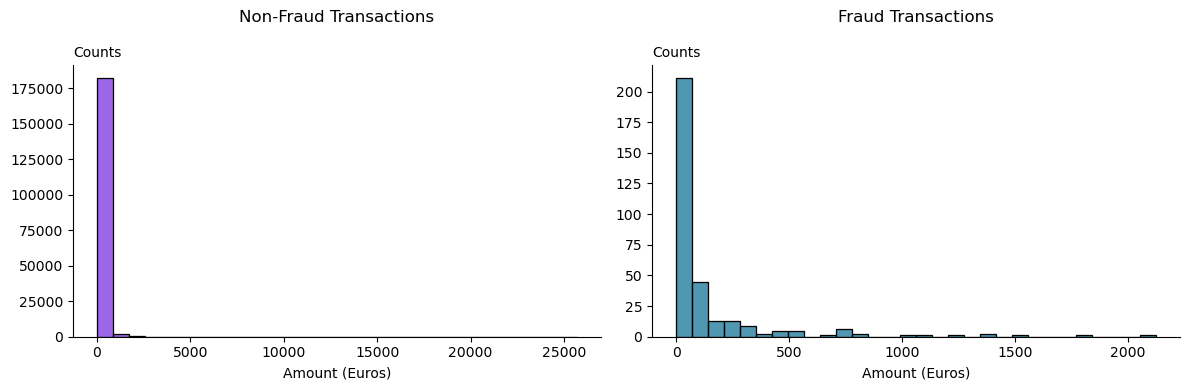

In [9]:
# Create side-by-side histograms for non-fraud and fraud transactions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram for Non-Fraud Transactions (outcome = 0)
sns.histplot(
    data=df[df['outcome'] == 0],
    x="Amount",
    bins=30,
    color="#7c31e4",
    ax=axes[0]
)
axes[0].set_title("Non-Fraud Transactions\n\n")
axes[0].set_xlabel("Amount (Euros)")
axes[0].set_ylabel("Counts", rotation=0, ha='left')
axes[0].yaxis.set_label_coords(0, 1.02)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Histogram for Fraud Transactions (outcome = 1)
sns.histplot(
    data=df[df['outcome'] == 1],
    x="Amount",
    bins=30,
    color="#157497",
    ax=axes[1]
)
axes[1].set_title("Fraud Transactions\n\n")
axes[1].set_xlabel("Amount (Euros)")
axes[1].set_ylabel("Counts", rotation=0, ha='left')
axes[1].yaxis.set_label_coords(0, 1.02)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# Adjust layout, save figure, increment figure counter, and display
plt.tight_layout()
plt.savefig(
    f'figures/{fig_count:02d}_histograms.png',
    dpi=300,
    bbox_inches='tight'
)
fig_count += 1
plt.show()


### Generating Figure 4

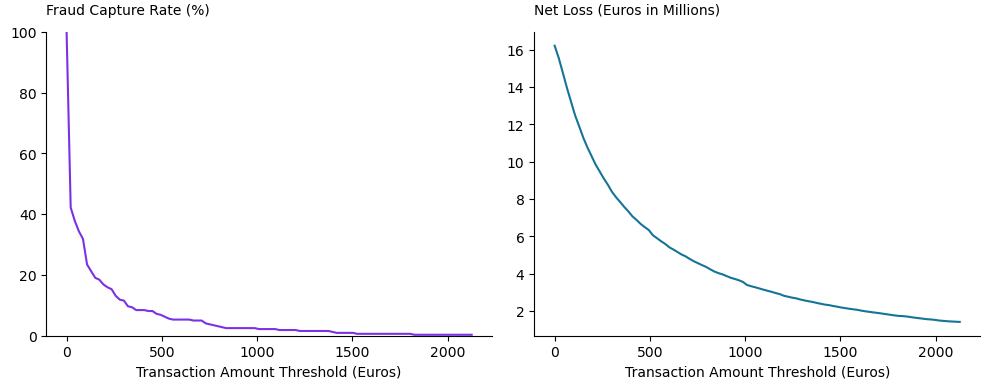

In [10]:
# Load data
y_actual = df["outcome"]
is_fraud = y_actual == 1


# Threshold function
def thresholds_fraud(amounts, threshold):
    return (amounts >= threshold).astype(int)


# Define thresholds to test
min_fraud_amount = df.loc[is_fraud, "Amount"].min()
max_fraud_amount = df.loc[is_fraud, "Amount"].max()
thresholds = np.linspace(min_fraud_amount, max_fraud_amount, 100)

# Store metrics
fraud_capture_rates = []
detection_rates = []
net_savings = []

for t in thresholds:
    y_pred = thresholds_fraud(df["Amount"], t)

    # Fraud Capture Rate
    true_positives = ((y_pred == 1) & (y_actual == 1)).sum()
    actual_positives = (y_actual == 1).sum()
    fraud_capture_rate = (
        true_positives / actual_positives if actual_positives > 0 else 0
    )
    fraud_capture_rates.append(fraud_capture_rate)

    # Precision / Detection Rate
    predicted_positives = (y_pred == 1).sum()
    precision = (
        true_positives / predicted_positives
        if predicted_positives > 0
        else 0
    )
    detection_rates.append(precision)

    # Net Savings Score
    true_positives_mask = (y_pred == 1) & (y_actual == 1)
    false_positives_mask = (y_pred == 1) & (y_actual == 0)
    tp_sum = df.loc[true_positives_mask, "Amount"].sum()
    fp_sum = df.loc[false_positives_mask, "Amount"].sum()
    net_savings.append(tp_sum - fp_sum)

# Scale net savings to millions
net_savings_millions = np.array(net_savings) / 1e6
fraud_capture_rates_percent = np.array(fraud_capture_rates) * 100

# Create combined figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# Fraud Capture Rate
axes[0].plot(thresholds, fraud_capture_rates_percent, color="#7c31e4")
axes[0].set_ylabel("Fraud Capture Rate (%)", rotation=0, ha="left")
axes[0].set_ylim(0, 100)

# Net Savings Score in Millions
axes[1].plot(thresholds, -net_savings_millions, color="#157497")
axes[1].set_ylabel("Net Loss (Euros in Millions)", rotation=0, ha="left")

# Style axes
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("Transaction Amount Threshold (Euros)")
    ax.yaxis.set_label_coords(0, 1.05)

plt.tight_layout()
plt.savefig(
    f"figures/{fig_count:02d}_thresholds.png", dpi=300, bbox_inches="tight"
)
fig_count += 1
plt.show()


### Generate Figure 5

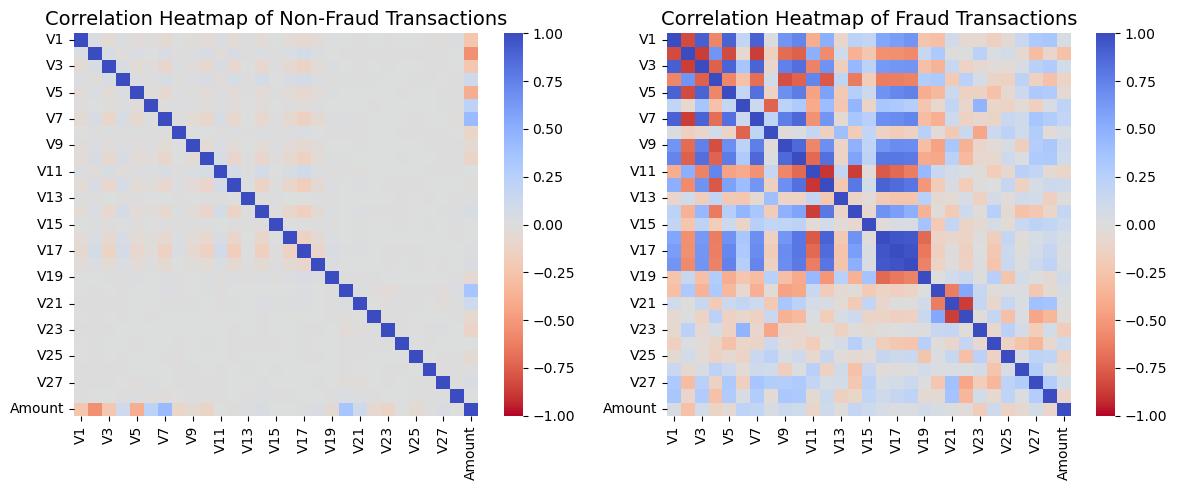

In [11]:
# Split dataset by fraud label
is_fraud = df["outcome"] == 1
df_0 = df[~is_fraud]  # Non-fraudulent transactions
df_1 = df[is_fraud]   # Fraudulent transactions

# Compute correlation matrices (excluding the outcome column)
corr_0 = df_0.iloc[:, :-1].corr()
corr_1 = df_1.iloc[:, :-1].corr()

# Plot side-by-side heatmaps for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap for non-fraudulent transactions
sns.heatmap(
    corr_0,
    cmap="coolwarm_r",
    vmax=1,
    vmin=-1,
    center=0,
    annot=False,
    cbar=True,
    ax=axes[0],
)
axes[0].set_title("Correlation Heatmap of Non-Fraud Transactions", fontsize=14)

# Heatmap for fraudulent transactions
sns.heatmap(
    corr_1,
    cmap="coolwarm_r",
    vmax=1,
    vmin=-1,
    center=0,
    annot=False,
    cbar=True,
    ax=axes[1],
)
axes[1].set_title("Correlation Heatmap of Fraud Transactions", fontsize=14)

# Adjust layout, save figure, increment figure counter, and display
plt.tight_layout()
plt.savefig(
    f"figures/{fig_count:02d}_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
fig_count += 1
plt.show()


### Generate Figure 6

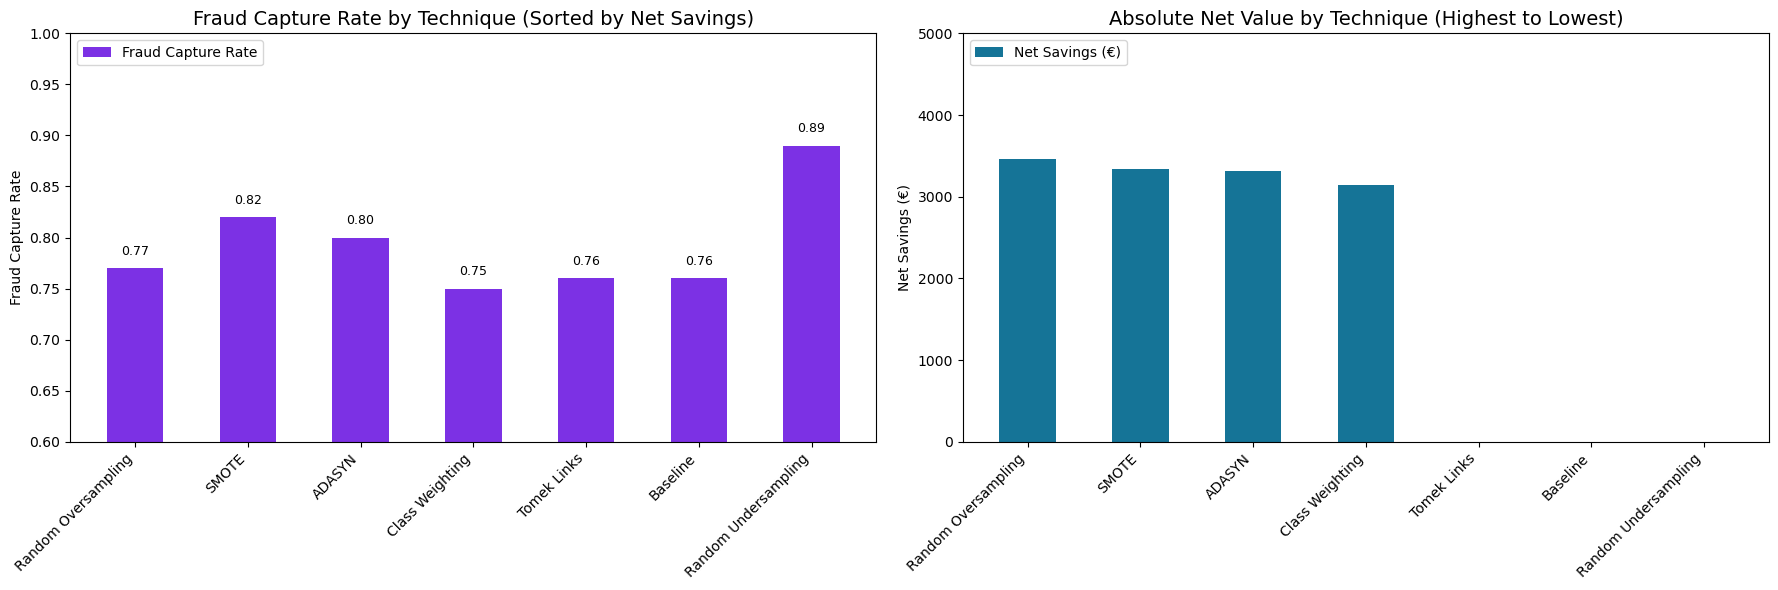

In [12]:
# Load summary statistics CSV for traditional techniques
sum_df = pd.read_csv("spreadsheets/summary_statistics.csv")

# Convert all relevant columns to numeric, ignoring commas
for col in sum_df.columns[1:]:
    sum_df[col] = pd.to_numeric(
        sum_df[col]
        .astype(str)
        .str.replace(",", ""),
        errors="coerce"
    )

# Extract relevant rows for metrics
rate_values = sum_df.iloc[3, 1:].values  # Fraud Capture Rate row
value_values = sum_df.iloc[5, 1:].values  # Absolute Net Value row
techniques = sum_df.columns[1:].tolist()  # Technique names from columns

# Sort techniques by Net Savings in descending order
sorted_indices = np.argsort(value_values)[::-1]
techniques = np.array(techniques)[sorted_indices]
value_values = value_values[sorted_indices]
rate_values = rate_values[sorted_indices]

# Define positions and width for bar plots
x_pos = np.arange(len(techniques))
bar_width = 0.5

# Create figure with 2 subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# -------------------------
# Plot 1: Fraud Capture Rate
# -------------------------
bars1 = ax[0].bar(
    x_pos,
    rate_values,
    bar_width,
    color="#7c31e4",
    label="Fraud Capture Rate"
)

ax[0].set_title(
    "Fraud Capture Rate by Technique (Sorted by Net Savings)", fontsize=14
)
ax[0].set_ylabel("Fraud Capture Rate")
ax[0].set_xticks(x_pos)
ax[0].set_xticklabels(techniques, rotation=45, ha="right")
ax[0].set_ylim(0.6, 1.0)

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.01,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax[0].legend(loc="upper left")

# -----------------------------
# Plot 2: Absolute Net Value
# -----------------------------
bars2 = ax[1].bar(
    x_pos,
    value_values,
    bar_width,
    color="#157497",
    label="Net Savings (€)"
)

ax[1].set_title(
    "Absolute Net Value by Technique (Highest to Lowest)", fontsize=14
)
ax[1].set_ylabel("Net Savings (€)")
ax[1].set_xticks(x_pos)
ax[1].set_xticklabels(techniques, rotation=45, ha="right")
ax[1].set_ylim(bottom=0, top=5000)
ax[1].legend(loc="upper left")

# Adjust layout, save figure, increment figure counter, and display
plt.tight_layout()
plt.savefig(
    f"figures/{fig_count:02d}_tradsum.png",
    dpi=300,
    bbox_inches="tight"
)
fig_count += 1
plt.show()

### Generate Figure 7

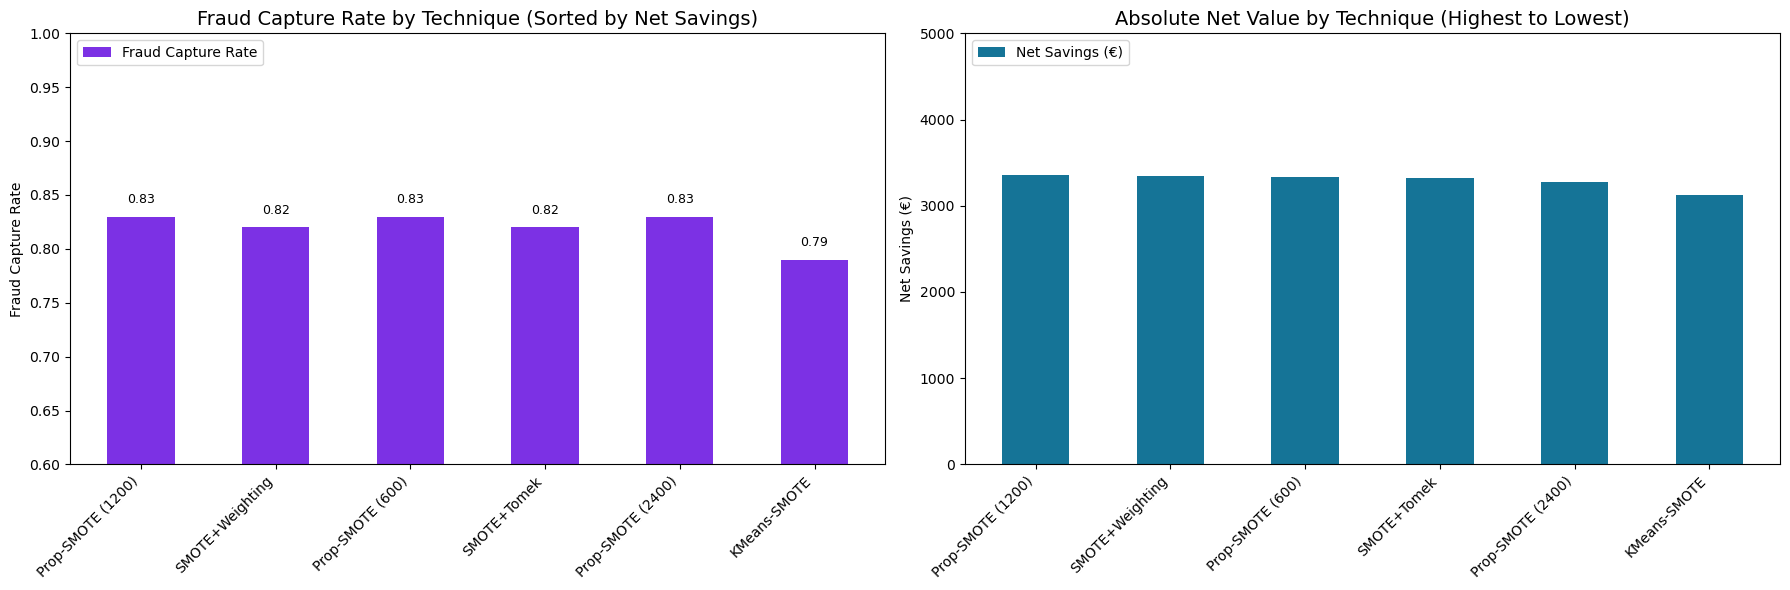

In [13]:
# Load the CSV file containing SMOTE experiment statistics
file = "spreadsheets/summary_smote_experiments_statistics.csv"
smote_df = pd.read_csv(file)

# Convert all columns to numeric, removing commas and coercing errors
for col in smote_df.columns:
    smote_df[col] = pd.to_numeric(
        smote_df[col]
        .astype(str)
        .str.replace(",", ""),
        errors="coerce"
    )

# Extract relevant rows for metrics
rate_values = smote_df.iloc[3, 0:].values  # Fraud Capture Rate row
value_values = smote_df.iloc[5, 0:].values  # Absolute Net Value row
techniques = smote_df.columns.tolist()  # Technique names from columns

# Sort techniques by Net Savings in descending order
sorted_indices = np.argsort(value_values)[::-1]
techniques = np.array(techniques)[sorted_indices]
value_values = value_values[sorted_indices]
rate_values = rate_values[sorted_indices]

# Define positions and width for bar plots
x_pos = np.arange(len(techniques))
bar_width = 0.5

# Create figure with 2 subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# -------------------------
# Plot 1: Fraud Capture Rate
# -------------------------
bars1 = ax[0].bar(
    x_pos,
    rate_values,
    bar_width,
    color="#7c31e4",
    label="Fraud Capture Rate"
)

ax[0].set_title(
    "Fraud Capture Rate by Technique (Sorted by Net Savings)", fontsize=14
)
ax[0].set_ylabel("Fraud Capture Rate")
ax[0].set_xticks(x_pos)
ax[0].set_xticklabels(techniques, rotation=45, ha="right")
ax[0].set_ylim(0.6, 1.0)

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.01,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax[0].legend(loc="upper left")

# -----------------------------
# Plot 2: Absolute Net Value
# -----------------------------
bars2 = ax[1].bar(
    x_pos,
    value_values,
    bar_width,
    color="#157497",
    label="Net Savings (€)"
)

ax[1].set_title(
    "Absolute Net Value by Technique (Highest to Lowest)", fontsize=14
)
ax[1].set_ylabel("Net Savings (€)")
ax[1].set_xticks(x_pos)
ax[1].set_xticklabels(techniques, rotation=45, ha="right")
ax[1].set_ylim(bottom=0, top=5000)
ax[1].legend(loc="upper left")

# Adjust layout, save figure, increment figure counter, and display
plt.tight_layout()
plt.savefig(
    f"figures/{fig_count:02d}_smotesum.png",
    dpi=300,
    bbox_inches="tight"
)
fig_count += 1
plt.show()
